(03-16-vroege-anomalieen)=

# Basu, Banz en Rosenberg

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1960–1993, met het zwaartepunt tussen 1977 en 1985.

**Wat we al weten.** [Het CAPM](#02-08-capm) zegt dat alleen bèta het verwachte
rendement bepaalt, en de eerste toetsen vonden een security market line die te
vlak was maar wel positief. [De CRSP-tape](#02-05-crsp-tape) liet zien dat de
constructie van een database een size-premie kan maken of breken. En
[Shiller](#03-15-shiller-excess-volatility) liet zien dat de *markt als geheel*
meer beweegt dan haar dividenden rechtvaardigen. Die barst zat in de tijdreeks.

**Welke vraag staat open.** Voorspellen eenvoudige kenmerken van een aandeel,
zoals de winst-koersverhouding, de marktwaarde of de boekwaarde, het gemiddelde
rendement beter dan bèta? En zo ja: is dat risico of een vergissing?
```

## Overzicht

Tussen 1977 en 1985 verschenen vier artikelen die elk één kenmerk van een aandeel
naast de bèta legden en telkens hetzelfde vonden: aandelen die op dat kenmerk
"goedkoop" of "klein" waren, verdienden meer dan het CAPM toestond.
{cite:t}`Basu1977` deed het met de koers-winstverhouding, {cite:t}`Banz1981` met
de marktwaarde, {cite:t}`Reinganum1981` met beide tegelijk, en
{cite:t}`RosenbergReidLanstein1985` met de verhouding van boekwaarde tot
marktwaarde, na een voorloper van {cite:t}`Stattman1980`. {cite:t}`Keim1983`
voegde toe dat een groot deel van het size-effect in één maand zat: januari.
{cite:t}`Bhandari1988` vond hetzelfde patroon voor de schuld-eigen-vermogenratio.
Het woord *anomalie* (een regelmaat in gemiddelde rendementen die het heersende
model niet verklaart) kreeg in deze jaren zijn betekenis in de financiële
economie.

Die artikelen definiëren het tijdvak omdat ze de epistemische status van het CAPM
veranderden. Het CAPM bleef een getoetste theorie, maar nu een met bekende
afwijkingen, en er was nog geen alternatief model dat die afwijkingen voorspelde.
Dat is motief 3 halverwege: de theorie wordt niet vervangen, ze krijgt een lijst
met uitzonderingen. Tegelijk bouwde Barr Rosenberg in Berkeley op dezelfde
kenmerken iets heel anders: geen toets van een evenwichtsmodel, maar een
risicomodel voor de praktijk {cite}`RosenbergMcKibben1973,Rosenberg1974`. En aan
het eind van het tijdvak kwamen de eerste waarschuwingen dat een regelmaat die
iemand in de data heeft gezocht, per constructie ook in de data te vinden is
{cite}`LoMacKinlay1990,Black1993`.

We bouwen de methode van onderaf op: een portefeuillesortering is een
niet-parametrische regressie, de alfa van een long-short-portefeuille een
Jensen-alfa met een eigen standaardfout, en Fama-MacBeth met kenmerken dezelfde
sortering met lineaire gewichten. Twee resultaten relativeren daarna elke
anomalie: marktwaarde *moet* verwachte rendementen voorspellen zodra die
verschillen {cite}`Berk1995`, en een zwakke correlatie tussen kenmerk en
steekproef maakt een grote $t$-waarde {cite}`LoMacKinlay1990`. Aan het eind
repliceren we de CAPM-alfa's van E/P-, B/M- en size-portefeuilles in de
steekproeven van Basu, Banz en Rosenberg-Reid-Lanstein en daarna, en het
januari-effect van Keim.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

In juli 1960 publiceerde S. Francis Nicholson in de *Financial Analysts Journal*
een artikel van drie pagina's over koers-winstverhoudingen
{cite}`Nicholson1960`. Hij vroeg analisten en zakenmensen welke aandelen het
over drie tot tien jaar beter zouden doen: die met een koers boven 25 keer de
winst of die onder 12 keer. De antwoorden waren bijna tien tegen één in het voordeel van de dure aandelen.
De latere literatuur citeert Nicholson als vroeg bewijs dat juist de goedkope het
beter deden; zijn tabellen hebben we niet kunnen inzien. Er was in 1960 nog geen
model waartegen "beter" kon worden gemeten. Zeventien jaar later was dat model er wel, en toen stelde Basu
dezelfde vraag opnieuw, nu met bèta's.

Waarom zou een goedkoop aandeel meer opleveren? Er zijn twee verhalen die hetzelfde
feit voorspellen. Het eerste is een rekensom. De koers is de contante waarde van de
toekomstige kasstromen; van twee bedrijven met dezelfde verwachte winst is het
riskantere goedkoper, *omdat* het meer moet opleveren. Een lage koers ten opzichte
van de winst is dan een hoge discontovoet, gemeten via de prijs, en als het CAPM dat
risico niet ziet, verschijnt het als alfa. Voor marktwaarde geldt hetzelfde: een
klein bedrijf is deels klein *omdat* zijn kasstromen zwaar worden verdisconteerd.

Het tweede verhaal is psychologie. Beleggers extrapoleren: bedrijven met slechte
recente winsten worden te somber gewaardeerd, bedrijven met mooie groeiverhalen
te optimistisch. De koers-winstverhouding meet dan niet het risico maar de
vergissing, en het hogere rendement van goedkope aandelen is de correctie die
langzaam komt. Dat is het verhaal van Nicholsons analisten, en van De Bondt en
Thaler, die we tegenkomen in [](#04-23-behavioral).

Beide verhalen voorspellen hetzelfde feit, dus gemiddelde rendementen sorteren
kan ze niet scheiden; het kan hooguit laten zien *dat* er iets is. Zelfs dat is
minder zeker dan het lijkt. Gemiddelde rendementen zijn slecht gemeten, dus wie
veel kenmerken probeert, vindt er altijd een paar die "werken" (Lo en MacKinlay).
En een kenmerk dat met de koers is berekend, correleert automatisch met het
verwachte rendement, ook als de prijs klopt (Berk).

## Toy-voorbeeld: vijf aandelen, twee portefeuilles

Vijf aandelen, één periode. Van elk kennen we de bèta, de winst-koersverhouding
E/P (winst gedeeld door koers, het omgekeerde van de P/E), de marktwaarde ME aan
het begin van de periode, en het gerealiseerde rendement $R$. De risicovrije
rente is $R^{f} - 1 = 1\%$.

| aandeel | $\beta_{i,m}$ | E/P | ME | $R - 1$ |
|---|---|---|---|---|
| A | 1,10 | 3% | 500 | 5,0% |
| B | 1,00 | 5% | 250 | 6,1% |
| C | 0,90 | 6% | 125 | 7,0% |
| D | 0,80 | 9% | 75 | 8,0% |
| E | 0,55 | 12% | 50 | 10,0% |

**De markt.** De marktgewichten zijn ME gedeeld door 1000:
$(0{,}50;\ 0{,}25;\ 0{,}125;\ 0{,}075;\ 0{,}05)$. Het marktrendement is
$0{,}50 \cdot 5 + 0{,}25 \cdot 6{,}1 + 0{,}125 \cdot 7 + 0{,}075 \cdot 8 + 0{,}05
\cdot 10 = 2{,}5 + 1{,}525 + 0{,}875 + 0{,}6 + 0{,}5 = 6{,}0\%$, dus het excess
marktrendement is $5{,}0\%$. De marktgewogen bèta is
$0{,}55 + 0{,}25 + 0{,}1125 + 0{,}06 + 0{,}0275 = 1{,}000$, zoals het hoort.

**De alfa per aandeel.** Met één periode is de gerealiseerde Jensen-alfa het
excess rendement min bèta maal het excess marktrendement:
$\alpha_A = 4{,}0 - 1{,}10 \cdot 5 = -1{,}50\%$,
$\alpha_B = 5{,}1 - 5{,}00 = 0{,}10\%$,
$\alpha_C = 6{,}0 - 4{,}50 = 1{,}50\%$,
$\alpha_D = 7{,}0 - 4{,}00 = 3{,}00\%$,
$\alpha_E = 9{,}0 - 2{,}75 = 6{,}25\%$.
Marktgewogen tellen ze op tot
$-0{,}75 + 0{,}025 + 0{,}1875 + 0{,}225 + 0{,}3125 = 0$: de markt heeft ten
opzichte van zichzelf per definitie geen alfa.

**De sortering.** Zet de twee aandelen met de hoogste E/P (D en E) in portefeuille
H en de twee met de laagste (A en B) in L, elk gelijkgewogen; C valt tussen de
breekpunten. Dan

| | bèta | excess rendement | CAPM-voorspelling | alfa |
|---|---|---|---|---|
| H = (D, E) | 0,675 | 8,00% | 3,375% | 4,625% |
| L = (A, B) | 1,050 | 4,55% | 5,250% | −0,700% |
| H − L | −0,375 | 3,45% | −1,875% | 5,325% |

Het excess rendement van H is $(7 + 9)/2 = 8{,}00\%$, haar bèta
$(0{,}80 + 0{,}55)/2 = 0{,}675$. De long-short-portefeuille H − L kost niets: haar
"excess rendement" is gewoon het verschil, $3{,}45\%$, en haar bèta het verschil
van de bèta's, $-0{,}375$. Haar alfa is
$3{,}45 - (-0{,}375)(5{,}0) = 3{,}45 + 1{,}875 = 5{,}325\%$, precies het verschil
van de twee alfa's. Het ruwe verschil onderschat de alfa hier, omdat de
goedkope aandelen een *lagere* bèta hebben: het CAPM voorspelt voor H − L een
negatief rendement, en elk positief rendement is dus alfa.

Twee dingen vallen op. Het eerste: sorteer op marktwaarde in plaats van op E/P,
en je krijgt exact dezelfde twee portefeuilles, want in dit voorbeeld zijn de
goedkoopste aandelen ook de kleinste. Of dit een E/P-effect of een size-effect
is, kan de sortering niet zeggen. Dat was precies het punt van
{cite:t}`Reinganum1981`. Het tweede: dit is één periode. Een gerealiseerde alfa
van 5,3% zegt niets zolang we niet weten hoe groot hij toevallig kan zijn. Daarvoor
is een tijdreeks nodig, en dat is de theorie hieronder.

In [2]:
toy = pd.DataFrame(
    {"beta": [1.10, 1.00, 0.90, 0.80, 0.55],
     "E/P": [0.03, 0.05, 0.06, 0.09, 0.12],
     "ME": [500.0, 250.0, 125.0, 75.0, 50.0],
     "R": [0.050, 0.061, 0.070, 0.080, 0.100]},
    index=list("ABCDE"),
)
rf_toy = 0.01
weights = toy["ME"] / toy["ME"].sum()
r_market = weights @ toy["R"]
toy["alfa"] = toy["R"] - rf_toy - toy["beta"] * (r_market - rf_toy)


def toy_portfolio(stocks):
    """Equal-weighted beta, excess return, CAPM prediction and alpha."""
    g = toy.loc[stocks]
    beta, excess = g["beta"].mean(), g["R"].mean() - rf_toy
    return pd.Series({"bèta": beta, "excess": excess,
                      "CAPM": beta * (r_market - rf_toy), "alfa": g["alfa"].mean()})


high_ep = toy.nlargest(2, "E/P").index
low_ep = toy.nsmallest(2, "E/P").index
sorted_toy = pd.DataFrame({"H": toy_portfolio(high_ep), "L": toy_portfolio(low_ep)}).T
sorted_toy.loc["H - L"] = sorted_toy.loc["H"] - sorted_toy.loc["L"]

hand = np.array([[0.675, 0.0800, 0.03375, 0.04625],
                 [1.050, 0.0455, 0.05250, -0.00700],
                 [-0.375, 0.0345, -0.01875, 0.05325]])
print(f"marktrendement = {r_market:.4f}, marktbèta = {weights @ toy['beta']:.4f}, "
      f"marktgewogen alfa = {weights @ toy['alfa']:.1e}")
print("code == handberekening:", np.allclose(sorted_toy.to_numpy(), hand))
print("zelfde portefeuilles bij sortering op ME:",
      set(toy.nsmallest(2, "ME").index) == set(high_ep))
sorted_toy.round(5)

marktrendement = 0.0600, marktbèta = 1.0000, marktgewogen alfa = 2.6e-18
code == handberekening: True
zelfde portefeuilles bij sortering op ME: True


,bèta,excess,CAPM,alfa
H,0.675,0.0800,0.03375,0.04625
L,1.050,0.0455,0.05250,-0.00700
H - L,-0.375,0.0345,-0.01875,0.05325


## Theorie

### Sorteren als niet-parametrische regressie

We schrijven $z_{i,t}$ voor een kenmerk van aandeel $i$ dat op $t$ bekend is, zoals
E/P, $\log \mathrm{ME}$ of B/M, en $R^{e}_{i,t+1}$ voor het excess rendement
daarna.

*Waarom zou dit waar zijn?* De vraag "voorspelt E/P het rendement?" is een vraag
naar de conditionele verwachting $\E_t[R^{e}_{i,t+1} \mid z_{i,t} = z]$ als
functie van $z$. Die functie kennen we niet, en niets zegt dat ze lineair is. De
eenvoudigste schatter van een onbekende functie is: deel de as in vakjes en neem
per vakje het gemiddelde. Dat is precies wat een portefeuillesortering doet.

Laat $g(z) = \E[R^{e}_{i,t+1} \mid z_{i,t} = z]$ en laat
$q_0 < q_1 < \dots < q_{J}$ de breekpunten zijn (bijvoorbeeld decielen van
$z_{i,t}$ op $t$). Het gelijkgewogen rendement van portefeuille $j$ is

```{math}
:label: eq-vroege-anomalieen-sort
R^{e}_{j,t+1} = \frac{1}{N_{j,t}} \sum_{i:\ q_{j-1} < z_{i,t} \le q_j} R^{e}_{i,t+1},
\qquad
\E\!\left[R^{e}_{j,t+1}\right] = \E\!\left[g(z_{i,t}) \mid q_{j-1} < z_{i,t} \le q_j\right].
```

Het tijdgemiddelde van $R^{e}_{j,t+1}$ schat dus de gemiddelde waarde van $g$ op
vakje $j$: een *partitieschatter* (histogramregressie). Meer vakjes geven minder
bias en meer ruis per vakje. Tien decielen kiezen voor weinig ruis, met als prijs
dat een effect in de kleinste paar procent van de aandelen, zoals dat van Banz, over
het hele eerste deciel wordt uitgesmeerd.

Het vak koos sorteringen om dezelfde reden als in [](#02-08-capm): portefeuilles
diversifiëren de ruis weg en maken hun bèta nauwkeurig meetbaar, zonder een
functionele vorm voor $g$ op te leggen. Dat laatste deed ertoe: Banz vond dat het
verband tussen marktwaarde en rendement niet lineair is.

### De alfa van een long-short-portefeuille

*Waarom zou dit waar zijn?* De vraag of het kenmerk iets toevoegt aan het CAPM is
de vraag of het verschil tussen de uiterste portefeuilles méér oplevert dan hun
verschil in bèta rechtvaardigt. Een portefeuille die de ene long en de andere
short houdt, kost niets en heeft precies die alfa. Haar alfa schatten is een
tijdreeksregressie zoals in [](#eq-capm-tijdreeks), op één reeks.

Laat $r^{\mathrm{LS}}_{t+1} = R^{e}_{J,t+1} - R^{e}_{1,t+1}$ het rendement zijn van
de hoogste min de laagste portefeuille, en schat over $T$ perioden

```{math}
:label: eq-vroege-anomalieen-ls
r^{\mathrm{LS}}_{t+1} = \alpha_{\mathrm{LS}} + \beta_{\mathrm{LS}}\, R^{e}_{m,t+1} + \varepsilon_{t+1}.
```

Omdat OLS lineair is in $y$, is $\hat\alpha_{\mathrm{LS}} = \hat\alpha_J - \hat\alpha_1$,
zoals in het toy-voorbeeld. Het nieuwe is de standaardfout.

:::{prf:proposition} Standaardfout van een tijdreeksalfa
:label: prop-vroege-anomalieen-se

Laat $\varepsilon_{t+1}$ in [](#eq-vroege-anomalieen-ls) onafhankelijk zijn van de
marktrendementen, met gemiddelde nul en variantie $\sigma_\varepsilon^2$, en laat
$\hat\mu_m$ en $\hat\sigma_m$ het steekproefgemiddelde en de ML-standaarddeviatie
van $R^{e}_{m,t+1}$ zijn. Dan is, gegeven de marktrendementen,

```{math}
:label: eq-vroege-anomalieen-se
\Var\!\left(\hat\alpha_{\mathrm{LS}}\right)
= \frac{\sigma_\varepsilon^2}{T}\left(1 + \frac{\hat\mu_m^2}{\hat\sigma_m^2}\right).
```
:::

:::{prf:proof}
Met $\mathbf{X} = [\mathbf{1}, \mathbf{f}]$ is
$\Var(\hat{\boldsymbol{\theta}} \mid \mathbf{X}) = \sigma_\varepsilon^2 (\mathbf{X}'\mathbf{X})^{-1}$,
en
$\mathbf{X}'\mathbf{X} = T\begin{pmatrix} 1 & \hat\mu_m \\ \hat\mu_m & \hat\sigma_m^2 + \hat\mu_m^2 \end{pmatrix}$.
Het $(1,1)$-element van de inverse is
$(\hat\sigma_m^2 + \hat\mu_m^2)/(T\hat\sigma_m^2)$. $\square$
:::

Met een maandelijkse Sharpe-ratio van de markt rond 0,13 is de correctieterm
$1{,}02$: de standaardfout is praktisch $\sigma_\varepsilon/\sqrt{T}$. Bij een
residuele volatiliteit van 5% per maand en veertig jaar data is dat
$5/\sqrt{480} \approx 0{,}23\%$ per maand, bijna 3% per jaar. Dat is motief 1 in de
cross-sectie: de steekproeven van Basu (veertien jaar) en Rosenberg, Reid en
Lanstein (twaalf jaar) konden alleen grote effecten significant maken.

### Fama-MacBeth met kenmerken

*Waarom zou dit waar zijn?* In [](#02-08-capm) was de Fama-MacBeth-helling
$\hat\gamma_{1,t}$ het rendement van een portefeuille met bèta één en kosten nul.
Vervang bèta door een kenmerk, en de helling wordt het rendement van een
portefeuille die long gaat in aandelen met een hoog kenmerk en short in aandelen
met een laag kenmerk, met gewichten die lineair in het kenmerk zijn. Een sortering
gebruikt stapfuncties als gewichten, Fama-MacBeth rechte lijnen; verder is het
dezelfde handeling.

Per periode draaien we over $i = 1, \dots, N$

```{math}
:label: eq-vroege-anomalieen-fm
R^{e}_{i,t+1} = \gamma_{0,t+1} + \gamma_{1,t+1}\,\hat\beta_{i,t} + \gamma_{2,t+1}\, z_{i,t} + \eta_{i,t+1},
```

en rapporteren $\bar\gamma_2$ met de tijdreeksstandaardfout; dit is
`hap.stats.fama_macbeth`, met bèta en kenmerk als panels.

:::{prf:proposition} Een Fama-MacBeth-helling is een long-short-portefeuille
:label: prop-vroege-anomalieen-fm

Laat $\mathbf{X}_t = [\mathbf{1}, \mathbf{z}_t]$ met $\mathbf{z}_t$ niet constant.
Dan is de OLS-helling van $\mathbf{R}^{e}_{t+1}$ op $\mathbf{X}_t$ gelijk aan
$\hat\gamma_{1,t+1} = \sum_i w_{i,t} R^{e}_{i,t+1}$ met

```{math}
:label: eq-vroege-anomalieen-fmgewichten
w_{i,t} = \frac{z_{i,t} - \bar z_t}{\sum_j \left(z_{j,t} - \bar z_t\right)^2},
\qquad \sum_i w_{i,t} = 0, \qquad \sum_i w_{i,t}\, z_{i,t} = 1 .
```

Met meer regressoren zijn de gewichten die van de residuen van $z$ na
regressie op de andere regressoren; de portefeuille heeft dan bovendien
blootstelling nul aan die regressoren, dus bèta nul als bèta erin staat.
:::

:::{prf:proof}
De tweede rij van $(\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'$ voor een regressie op een
constante en één variabele is de bekende formule
$\hat\gamma_1 = \sum_i (z_i - \bar z) R_i / \sum_j (z_j - \bar z)^2$. De eigenschappen
volgen uit $\sum_i (z_i - \bar z) = 0$ en
$\sum_i (z_i - \bar z) z_i = \sum_i (z_i - \bar z)^2$. De uitbreiding naar meer
regressoren is het Frisch-Waugh-Lovell-theorema, en
$(\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'\mathbf{X} = \mathbf{I}$ zegt dat het
gewicht van regressor $k$ blootstelling één heeft aan $k$ en nul aan de rest.
$\square$
:::

In het toy-voorbeeld zijn de gewichten $(-8, -4, -2, 4, 10)$: dezelfde richting
als H − L, maar met C erbij en zwaardere uitersten.

In [3]:
z_toy = toy["E/P"]
X_toy = np.column_stack([np.ones(5), z_toy])
fm_weights = np.linalg.solve(X_toy.T @ X_toy, X_toy.T)[1]
pd.DataFrame(
    {"gewicht": fm_weights, "(z - gem.)/som kwadraten": (z_toy - z_toy.mean()) / ((z_toy - z_toy.mean())**2).sum()},
    index=toy.index,
).assign(**{"som w": fm_weights.sum(), "som w z": fm_weights @ z_toy}).round(4)

,gewicht,(z - gem.)/som kwadraten,som w,som w z
A,-8.0,-8.0,0.0,1.0
B,-4.0,-4.0,0.0,1.0
C,-2.0,-2.0,0.0,1.0
D,4.0,4.0,0.0,1.0
E,10.0,10.0,0.0,1.0


Fama-MacBeth kan meerdere kenmerken tegelijk nemen en beantwoordt zo Reinganums
vraag, E/P of size, in één regressie, waar een sortering een dubbele sortering nodig
heeft. De prijs is lineariteit: extreme kenmerkwaarden krijgen extreme gewichten.

### Waarom een kenmerk alfa oplevert: Berk

*Waarom zou dit waar zijn?* De marktwaarde van een bedrijf is zijn verwachte
kasstroom gedeeld door een discontovoet. Als bedrijven verschillende verwachte
rendementen hebben, om welke reden ook, dan hebben bedrijven met een hoog verwacht
rendement, bij verder gelijke kasstromen, een lage marktwaarde. Sorteren op
marktwaarde is dan sorteren op verwacht rendement, zonder dat iemand zich
vergist. En als het model waarmee we toetsen het risico mist dat die verwachte
rendementen drijft, meet marktwaarde precies het gemiste deel. {cite:t}`Berk1995`
concludeerde daaruit dat het *omgekeerde* een anomalie zou zijn: een wereld waarin
marktwaarde niet met verwacht rendement correleert.

We maken dat exact in het eenvoudigste model. Bedrijf $i$ heeft een verwachte
kasstroom $C_i$ volgend jaar, die met een constante groeivoet $g$ groeit, en een
constante discontovoet $k_i > g$. Volgens het Gordon-model uit
[](#01-03-williams-ddm) is

```{math}
:label: eq-vroege-anomalieen-gordon
\mathrm{ME}_i = \frac{C_i}{k_i - g},
\qquad
\log \mathrm{ME}_i = \log C_i - \log\left(k_i - g\right),
```

en $k_i$ is het verwachte rendement van het aandeel.

:::{prf:theorem} Marktwaarde voorspelt verwacht rendement (Berk)
:label: thm-vroege-anomalieen-berk

Laat [](#eq-vroege-anomalieen-gordon) gelden, met $\log C_i$ over de cross-sectie
onafhankelijk van $k_i$ en $k_i$ niet ontaard. Dan geldt:

1. $\Cov(\log \mathrm{ME}_i, k_i) < 0$.
2. Stel dat een onderzoeker een model gebruikt dat verwacht rendement $\hat k_i$
   toekent, en dat $k_i = \hat k_i + \alpha_i$ met $\alpha_i$ onafhankelijk van
   $\hat k_i$, van $\log C_i$, en niet ontaard. Dan is
   $\Cov(\log \mathrm{ME}_i, \alpha_i) < 0$: kleine bedrijven hebben gemiddeld een
   positieve alfa ten opzichte van het model, ook al is elke prijs correct.
:::

:::{prf:proof}
Schrijf $h(x) = \log(x - g)$, strikt stijgend op $x > g$.

(1) Door de onafhankelijkheid is
$\Cov(\log \mathrm{ME}_i, k_i) = -\Cov(h(k_i), k_i)$. Voor een strikt stijgende
functie $h$ en een onafhankelijke kopie $k'$ van $k$ is
$2\Cov(h(k), k) = \E[(h(k) - h(k'))(k - k')] > 0$, want de integrand is nooit
negatief en positief zodra $k \ne k'$, wat met positieve kans gebeurt.

(2) Opnieuw is $\Cov(\log \mathrm{ME}_i, \alpha_i) = -\Cov(h(\hat k_i + \alpha_i), \alpha_i)$.
Conditioneer op $\hat k_i$: omdat $\alpha_i$ er onafhankelijk van is, geeft het
argument van (1), toegepast op de stijgende functie $a \mapsto h(\hat k_i + a)$,
$\Cov(h(\hat k_i + \alpha_i), \alpha_i \mid \hat k_i) > 0$. Met de wet van de
totale covariantie,
$\Cov(h, \alpha) = \E[\Cov(h, \alpha \mid \hat k)] + \Cov(\E[h \mid \hat k], \E[\alpha \mid \hat k])$,
en omdat $\E[\alpha \mid \hat k]$ constant is, is de tweede term nul. $\square$
:::

Lineariseer $h$ rond $\bar k$ voor een orde van grootte:
$\Cov(\log \mathrm{ME}, k) \approx -\Var(k)/(\bar k - g)$ (oefening
[](#ex-vroege-anomalieen-1)). De correlatie is klein, omdat bedrijven vooral in de
omvang van hun kasstromen verschillen, maar in de limiet onvermijdelijk: size is
een ruisige maatstaf van verwacht rendement. Voor E/P en B/M is het argument
directer, want de noemer haalt een deel van de ruis in het kasstroomniveau weg.

De stelling zegt *niet* dat anomalieën risicopremies zijn: deel (2) werkt voor elke
$\alpha_i$, ook voor een alfa die ontstaat doordat beleggers kasstromen te zwaar
verdisconteren. Ze zegt dat een correlatie tussen marktwaarde en alfa geen bewijs
is van het een of het ander, en dat "klein zijn" op zich geen oorzaak is: size is
een thermometer.

### Fundamentele factormodellen: Rosenberg en BARRA

*Waarom zou dit waar zijn?* Als aandelen met dezelfde bedrijfstak, omvang of
schuldgraad samen bewegen, hoeft een risicomodel niet elke paarsgewijze covariantie
te schatten: de covariantie van een handvol factoren plus de blootstelling van elk
aandeel, afgelezen uit de balans, volstaat.

{cite:t}`RosenbergMcKibben1973` voorspelden de bèta en het specifieke risico van
aandelen met boekhoudkundige en marktgegevens in plaats van alleen met historische
rendementen. {cite:t}`Rosenberg1974` liet zien dat er naast de markt significante
gemeenschappelijke componenten in de covariantie van aandelenrendementen zitten,
en dat de ladingen van aandelen op die componenten worden bepaald door
waarneembare kenmerken van het bedrijf. In 1975 bracht zijn bedrijf Barra het
eerste commerciële multifactor-risicomodel voor Amerikaanse aandelen uit.

Het model schrijft

```{math}
:label: eq-vroege-anomalieen-barra
R^{e}_{i,t+1} = \sum_{k=1}^{K} x_{i,k,t}\, f_{k,t+1} + u_{i,t+1},
\qquad
\boldsymbol{\Sigma}_{t} = \mathbf{X}_t \mathbf{F} \mathbf{X}_t' + \boldsymbol{\Delta},
```

met $x_{i,k,t}$ de (gestandaardiseerde) blootstelling van aandeel $i$ aan factor
$k$, zoals bedrijfstak-dummy's, $\log \mathrm{ME}$, B/P of schuldgraad;
$f_{k,t+1}$ de factorrendementen, $\mathbf{F}$ hun covariantiematrix en
$\boldsymbol{\Delta}$ een diagonale matrix van specifieke varianties. De
blootstellingen zijn bekend; de factorrendementen worden elke periode geschat met
een cross-sectionele regressie van rendementen op blootstellingen: formeel
precies [](#eq-vroege-anomalieen-fm), en volgens
{prf:ref}`prop-vroege-anomalieen-fm` zijn de geschatte $f_{k,t+1}$ weer
rendementen van long-short-portefeuilles.

Het verschil met Fama-MacBeth zit in wat er daarna met de tijdreeks
$\hat f_{k,t+1}$ gebeurt, en dat verschil is motief 1. Fama-MacBeth neemt het
*gemiddelde* en vraagt of het van nul verschilt: een eerste moment, slecht
gemeten. Barra neemt de *covariantiematrix* $\mathbf{F}$ en gebruikt die om het
risico van een portefeuille te voorspellen: een tweede moment, goed gemeten. Met
$N$ aandelen heeft een vrije covariantiematrix $N(N+1)/2$ parameters, voor
duizend aandelen een half miljoen; een model met veertig factoren heeft er
$40 \cdot 41/2 + 1000 = 1820$. Rosenberg bouwde met dezelfde kenmerken dus een instrument dat werkte, terwijl
anderen er een theorie mee afbraken; wie elke maand factorrendementen voor B/P
schat, ziet vanzelf dat hun gemiddelde niet nul is.

### Data snooping: Lo en MacKinlay

*Waarom zou dit waar zijn?* Wie sorteert op een kenmerk dat hij koos *omdat* het in
de data iets leek te doen, sorteert deels op de toevalsfout in de rendementen die hij
daarna toetst, en de sortering zet precies de aandelen met de grootste fout in de
uiterste portefeuilles.

{cite:t}`LoMacKinlay1990` maakten dit formeel voor toetsen op portefeuilles die
zijn gesorteerd op een empirisch gemotiveerd kenmerk zoals marktwaarde, en lieten
met analytische berekeningen, Monte-Carlosimulaties en twee empirische
voorbeelden zien dat het effect substantieel kan zijn. Hun eigen formules en
getallen hebben we niet in de primaire bron kunnen nalezen; hieronder staat een
eigen, eenvoudiger versie van hetzelfde mechanisme.

:::{prf:proposition} Sorteren op een kenmerk dat met de steekproefalfa correleert
:label: prop-vroege-anomalieen-snooping

Laat $N$ aandelen ware alfa nul hebben, met residuen die onafhankelijk zijn over
aandelen en perioden, variantie $\sigma^2$. Laat $\hat\alpha_i$ de alfa's uit $T$
perioden zijn, $s_i$ hun standaardisatie over de cross-sectie, en laat het
kenmerk $z_i = \rho\, s_i + \sqrt{1-\rho^2}\,\nu_i$ zijn met $\nu_i$ onafhankelijke
standaardnormale ruis. Sorteer de fractie $p$ met de hoogste $z$ long en de fractie
$p$ met de laagste short, elk gelijkgewogen met $n = pN$ aandelen. Dan is, voor
grote $N$ en onder normaliteit, de verwachte $t$-waarde van de
long-short-alfa *in dezelfde steekproef*

```{math}
:label: eq-vroege-anomalieen-snooping
\E[t_{\mathrm{LS}}] \approx \rho\,\sqrt{2n}\;\frac{\varphi(q_p)}{p},
\qquad q_p = \Phi^{-1}(1-p),
```

en buiten de steekproef is de verwachte $t$-waarde nul.
:::

:::{prf:proof}
Omdat OLS lineair is, is de long-short-alfa het verschil van de gemiddelde
$\hat\alpha_i$ in de twee groepen. Voor gezamenlijk normale $(s_i, z_i)$ met
correlatie $\rho$ is $\E[s \mid z] = \rho z$, en $\E[z \mid z > q_p] = \varphi(q_p)/p$
(de verwachting van een afgeknotte standaardnormale). De verwachte alfa is dus
$2\rho\,\mathrm{sd}(\hat\alpha)\,\varphi(q_p)/p$ met
$\mathrm{sd}(\hat\alpha) \approx \sigma/\sqrt{T}$. De residuele variantie van de
long-short-portefeuille is $2\sigma^2/n$, dus haar alfa heeft standaardfout
$\sqrt{2/n}\,\sigma/\sqrt{T}$ (de correctie uit
{prf:ref}`prop-vroege-anomalieen-se` is verwaarloosbaar). Delen geeft
[](#eq-vroege-anomalieen-snooping). Buiten de steekproef zijn de residuen
onafhankelijk van $z$, dus de verwachte alfa is nul. $\square$
:::

Met $N = 1000$ aandelen en decielen ($p = 0{,}1$, $n = 100$,
$\varphi(1{,}2816)/0{,}1 = 1{,}755$) is $\E[t] \approx 24{,}8\,\rho$: een kenmerk
dat voor één procent van zijn variantie ($\rho = 0{,}1$) uit steekproeffout
bestaat, geeft een verwachte $t$-waarde van 2,5. Omdat $n = pN$, groeit de
vertekening bij een vast aantal portefeuilles met $\sqrt{N}$. Wie een kenmerk
kiest dat "uit eerder onderzoek bekend" is, zit in dezelfde positie zodra dat
onderzoek dezelfde jaren gebruikte.

De grovere vorm van hetzelfde probleem is het proberen van veel kenmerken. Met $K$
onafhankelijke kandidaten zonder enig effect is de kans dat minstens één een
$t$-waarde boven 1,96 haalt $1 - 0{,}975^{K}$ (eenzijdig), bij $K = 20$ al 40%.
{cite:t}`Black1993` las de size- en waarde-effecten om deze reden als
waarschijnlijke datamining: regelmaten zonder een theorie die ze vooraf
voorspelde. De systematische versie van dat argument, met honderden
gepubliceerde anomalieën en een drempel van $t \ge 3$, is [](#06-34-factor-zoo).

## Simulatie: een size-effect zonder anomalie, en een anomalie zonder effect

Twee werelden waarvan we de waarheid kennen. In de eerste zijn alle prijzen correct,
maar toetst de onderzoeker met het verkeerde model; in de tweede geldt het CAPM
exact, maar kiest hij zijn kenmerk op basis van de steekproef.

### (a) Berk: een wereld met twee risico's

Er zijn 1000 aandelen met CAPM-bèta $\beta_i \sim 1 + 0{,}3\,\mathcal{N}(0,1)$ en een
tweede blootstelling $\delta_i \sim U(0; 1{,}5)$ aan een beprijsde factor $h$ die
onafhankelijk is van de markt, zoals een faillissements- of recessierisico. De
excess rendementen zijn

$$
R^{e}_{i,t+1} = \beta_i f_{m,t+1} + \delta_i f_{h,t+1} + \varepsilon_{i,t+1},
$$

met $\E[f_m] = 0{,}5\%$ en $\SD(f_m) = 4{,}5\%$, $\E[f_h] = 0{,}4\%$ en
$\SD(f_h) = 3\%$ per maand, en $\SD(\varepsilon) = 10\%$. Er is geen alfa ten opzichte
van het ware tweefactormodel. De marktwaarde volgt uit
[](#eq-vroege-anomalieen-gordon) met $k_i = 3\% + 12(0{,}5\%\,\beta_i + 0{,}4\%\,\delta_i)$
per jaar, $g = 2\%$, en een kasstroomniveau $\log C_i \sim \mathcal{N}(0; 1{,}5^2)$
dat niets met risico te maken heeft. We sorteren eenmalig op marktwaarde in tien
portefeuilles van honderd aandelen en simuleren 1000 steekproeven van veertig jaar.

In [4]:
def alpha_t(returns, factors):
    """OLS intercepts and t-statistics of every column of `returns` (T x K) on `factors` (T or T x L)."""
    X = np.column_stack([np.ones(len(returns)), factors])
    coef, *_ = np.linalg.lstsq(X, returns, rcond=None)
    resid = returns - X @ coef
    s2 = (resid**2).sum(axis=0) / (len(returns) - X.shape[1])
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[0, 0])
    return coef[0], coef[0] / se


n_stocks, n_groups, T_sim, n_samples = 1000, 10, 480, 1000
lam_m, sd_m, lam_h, sd_h, sd_eps = 0.005, 0.045, 0.004, 0.030, 0.10

beta_i = np.clip(1.0 + 0.3 * rng.standard_normal(n_stocks), 0.2, 1.8)
delta_i = rng.uniform(0.0, 1.5, n_stocks)
k_i = 0.03 + 12 * (lam_m * beta_i + lam_h * delta_i)      # expected return per year
log_me = rng.normal(0.0, 1.5, n_stocks) - np.log(k_i - 0.02)

group = np.empty(n_stocks, dtype=int)
group[np.argsort(log_me)] = np.arange(n_stocks) * n_groups // n_stocks   # 0 = smallest
count = np.bincount(group)
beta_p, delta_p = np.bincount(group, beta_i) / count, np.bincount(group, delta_i) / count

pd.DataFrame(
    {"corr met log ME": [np.corrcoef(log_me, x)[0, 1] for x in (k_i, beta_i, delta_i)]},
    index=["verwacht rendement k", "bèta", "delta"],
).round(3)

,corr met log ME
verwacht rendement k,-0.193
bèta,-0.123
delta,-0.150


In [5]:
berk = {"CAPM": [], "tweefactor": []}
for _ in range(n_samples):
    f_m = lam_m + sd_m * rng.standard_normal(T_sim)
    f_h = lam_h + sd_h * rng.standard_normal(T_sim)
    noise = sd_eps / np.sqrt(count) * rng.standard_normal((T_sim, n_groups))
    port = np.outer(f_m, beta_p) + np.outer(f_h, delta_p) + noise
    smb = port[:, 0] - port[:, -1]
    berk["CAPM"].append(alpha_t(smb, f_m))
    berk["tweefactor"].append(alpha_t(smb, np.column_stack([f_m, f_h])))
berk = {k: np.array(v) for k, v in berk.items()}          # (n_samples, 2): alpha, t

pd.DataFrame(
    {model: {"gem. alfa klein - groot (% p.m.)": 100 * v[:, 0].mean(),
             "theorie (% p.m.)": 100 * (delta_p[0] - delta_p[-1]) * lam_h if model == "CAPM" else 0.0,
             "gem. t": v[:, 1].mean(),
             "fractie t > 1.96": np.mean(v[:, 1] > 1.96)}
     for model, v in berk.items()}
).T.round(3)

,gem. alfa klein - groot (% p.m.),theorie (% p.m.),gem. t,fractie t > 1.96
CAPM,0.076,0.079,1.085,0.186
tweefactor,-0.002,0.000,-0.035,0.024


Sorteren op marktwaarde levert in deze wereld een CAPM-alfa van gemiddeld 0,076%
per maand op voor klein min groot, tegen 0,079% volgens de theorie: het verschil in
$\delta$ tussen de uiterste portefeuilles maal de premie van de gemiste factor. Ten
opzichte van het ware tweefactormodel is de alfa nul en haalt ze $t > 1{,}96$ in
2,4% van de steekproeven, zoals bij een eenzijdige toets hoort. De CAPM-alfa haalt
die drempel in 18,6%, met een gemiddelde $t$ van 1,09. Dat is motief 1: een correct
beprijsd verschil in verwachte rendementen van bijna een procentpunt per jaar
blijft na veertig jaar data meestal onzichtbaar. De correlatie tussen
$\log \mathrm{ME}$ en het verwachte rendement is maar $-0{,}19$, omdat de
kasstroomniveaus het grootste deel van de spreiding in marktwaarde bepalen.

Nu dezelfde wereld met individuele aandelen en Fama-MacBeth met kenmerken, via
`hap.stats.fama_macbeth`. We geven de regressie de *ware* bèta, zodat er geen
errors-in-variables zijn, en voegen $\log \mathrm{ME}$ toe (gestandaardiseerd).

In [6]:
f_m = lam_m + sd_m * rng.standard_normal(T_sim)
f_h = lam_h + sd_h * rng.standard_normal(T_sim)
stock_returns = pd.DataFrame(np.outer(f_m, beta_i) + np.outer(f_h, delta_i)
                             + sd_eps * rng.standard_normal((T_sim, n_stocks)))


def as_panel(values):
    """One-row characteristic frame, broadcast over all periods by fama_macbeth."""
    return pd.DataFrame([values], columns=stock_returns.columns)


size_z = (log_me - log_me.mean()) / log_me.std()
specs = {"bèta + log ME": {"bèta": as_panel(beta_i), "log ME": as_panel(size_z)},
         "bèta + delta + log ME": {"bèta": as_panel(beta_i), "delta": as_panel(delta_i),
                                   "log ME": as_panel(size_z)}}
fm_sim = {}
for name, chars in specs.items():
    out = hap.stats.fama_macbeth(stock_returns, chars, lags=0)
    out.attrs = {}
    fm_sim[name] = out[["estimate", "tstat"]].assign(estimate=lambda d: 100 * d["estimate"])
pd.concat(fm_sim).round(3)

estimate  tstat
bèta + log ME         const      0.611  5.582
                      bèta       0.017  0.085
                      log ME    -0.069 -4.184
bèta + delta + log ME const      0.169  2.874
                      bèta       0.025  0.122
                      delta      0.573  4.272
                      log ME    -0.031 -2.244

Met alleen bèta en marktwaarde is de coëfficiënt op $\log \mathrm{ME}$
$-0{,}069\%$ per maand per standaarddeviatie, met $t = -4{,}18$: marktwaarde
"verklaart" rendementen die bèta niet verklaart. Met de werkelijk beprijsde
blootstelling $\delta$ erbij halveert hij tot $-0{,}031\%$ ($t = -2{,}24$). In het
model is de ware coëfficiënt dan exact nul; dat hij in deze ene steekproef nog de
5%-drempel haalt, is toeval van het soort dat bij een tweezijdige toets één keer op
de twintig voorkomt.

### (b) Data snooping: kiezen wat werkt

Nu een wereld waarin het CAPM exact geldt: 500 aandelen zonder alfa, en 100
kandidaat-kenmerken die pure ruis zijn. Voor elk kenmerk vormt de onderzoeker een
long-short-portefeuille van de 50 hoogste en 50 laagste aandelen, schat de CAPM-alfa
over twintig jaar en rapporteert het kenmerk met de hoogste $t$-waarde. Daarna kijken
we naar de twintig jaar erna.

In [7]:
n_sn, n_leg, T_in, T_out, n_cand, n_rep = 500, 50, 240, 240, 100, 400


def ranks_to_long_short(z, n_long):
    """Weights: +1/n on the n highest, -1/n on the n lowest values in each row of z."""
    ranks = np.argsort(np.argsort(z, axis=-1), axis=-1)
    n = z.shape[-1]
    return ((ranks >= n - n_long).astype(float) - (ranks < n_long)) / n_long


snoop = []
for _ in range(n_rep):
    beta = 1.0 + 0.3 * rng.standard_normal(n_sn)
    f = lam_m + sd_m * rng.standard_normal(T_in + T_out)
    R = np.outer(f, beta) + sd_eps * rng.standard_normal((T_in + T_out, n_sn))
    P = R @ ranks_to_long_short(rng.standard_normal((n_cand, n_sn)), n_leg).T
    _, t_in = alpha_t(P[:T_in], f[:T_in])
    _, t_out = alpha_t(P[T_in:], f[T_in:])
    best = np.argmax(t_in)
    snoop.append((t_in[0], t_in[best], t_out[best]))
snoop = pd.DataFrame(snoop, columns=["één kenmerk", "beste van 100, in-sample", "beste van 100, out-of-sample"])

snoop.describe().loc[["mean", "std"]].T.assign(
    **{"fractie t > 1.96": (snoop > 1.96).mean(), "fractie t > 3": (snoop > 3).mean()}
).round(3)

,mean,std,fractie t > 1.96,fractie t > 3
één kenmerk,-0.056,0.978,0.018,0.00
"beste van 100, in-sample",2.478,0.437,0.925,0.12
"beste van 100, out-of-sample",-0.101,1.030,0.018,0.00


Eén vooraf gekozen kenmerk gedraagt zich zoals het hoort: gemiddelde $t$ van
$-0{,}06$, standaarddeviatie 0,98. Het beste van honderd heeft in-sample een
gemiddelde $t$-waarde van 2,48, haalt in 92,5% van de gevallen $t > 1{,}96$ en in
12% zelfs $t > 3$. Buiten de steekproef is er niets van over: gemiddelde $-0{,}10$,
en in 1,8% van de gevallen $t > 1{,}96$. Dat is geen anomalie die "verdwijnt na
publicatie", maar een die nooit heeft bestaan.

Tot slot de subtielere vorm uit {prf:ref}`prop-vroege-anomalieen-snooping`: één
kenmerk, maar een kenmerk dat een beetje met de in-sample alfa's correleert. We
toetsen [](#eq-vroege-anomalieen-snooping) voor $N = 1000$ en decielen.

In [8]:
def sorted_on_sample_alpha(rho, n=1000, T=240, n_long=100, reps=150):
    """Mean in- and out-of-sample t of a long-short sort on z = rho * std(alpha_hat) + noise."""
    t_in, t_out = [], []
    for _ in range(reps):
        beta = 1.0 + 0.3 * rng.standard_normal(n)
        f = lam_m + sd_m * rng.standard_normal(2 * T)
        R = np.outer(f, beta) + sd_eps * rng.standard_normal((2 * T, n))
        a_hat, _ = alpha_t(R[:T], f[:T])
        s = (a_hat - a_hat.mean()) / a_hat.std()
        z = rho * s + np.sqrt(1 - rho**2) * rng.standard_normal(n)
        ls = R @ ranks_to_long_short(z, n_long)
        t_in.append(alpha_t(ls[:T], f[:T])[1])
        t_out.append(alpha_t(ls[T:], f[T:])[1])
    p = n_long / n
    return {"t in-sample": np.mean(t_in), "t out-of-sample": np.mean(t_out),
            "formule": rho * np.sqrt(2 * n_long) * stats.norm.pdf(stats.norm.ppf(1 - p)) / p}


pd.DataFrame({rho: sorted_on_sample_alpha(rho) for rho in (0.0, 0.05, 0.10, 0.20)}).T.rename_axis("rho").round(3)

,t in-sample,t out-of-sample,formule
rho,,,
0.00,-0.082,-0.025,0.000
0.05,1.419,0.030,1.241
0.10,2.356,-0.088,2.482
0.20,4.981,0.150,4.964


De formule klopt: bij een correlatie van 0,05, 0,10 en 0,20 tussen kenmerk en
steekproeffout is de gemiddelde in-sample $t$-waarde 1,42, 2,36 en 4,98, tegen
1,24, 2,48 en 4,96 voorspeld, en buiten de steekproef ligt ze telkens binnen 0,15
van nul.

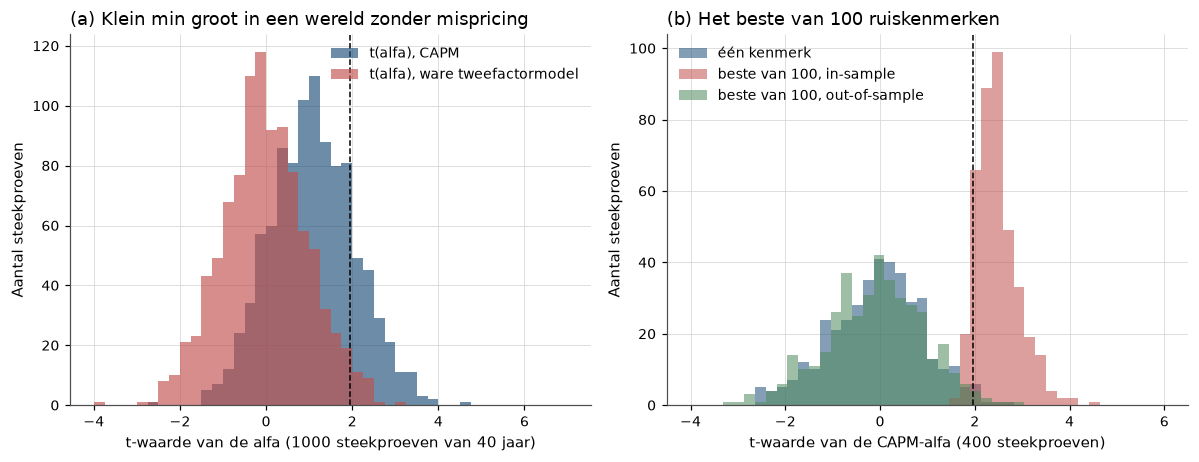

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
bins = np.linspace(-4, 7, 45)
axes[0].hist(berk["CAPM"][:, 1], bins=bins, alpha=0.65, label="t(alfa), CAPM")
axes[0].hist(berk["tweefactor"][:, 1], bins=bins, alpha=0.65, label="t(alfa), ware tweefactormodel")
axes[0].axvline(1.96, color="black", lw=1, ls="--")
axes[0].set_title("(a) Klein min groot in een wereld zonder mispricing")
axes[0].set_xlabel("t-waarde van de alfa (1000 steekproeven van 40 jaar)")
axes[0].set_ylabel("Aantal steekproeven")
axes[0].legend()

bins = np.linspace(-4, 6, 45)
for column in snoop.columns:
    axes[1].hist(snoop[column], bins=bins, alpha=0.55, label=column)
axes[1].axvline(1.96, color="black", lw=1, ls="--")
axes[1].set_title("(b) Het beste van 100 ruiskenmerken")
axes[1].set_xlabel("t-waarde van de CAPM-alfa (400 steekproeven)")
axes[1].set_ylabel("Aantal steekproeven")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-vroege-anomalieen-sim
:label: fig-vroege-anomalieen-sim
:width: 100%

Links: in een wereld waarin elke prijs correct is, levert een sortering op
marktwaarde een CAPM-alfa op, omdat marktwaarde de gemiste risicofactor meet; ten
opzichte van het ware model verdwijnt de alfa. Dat de verdeling breed is en
geregeld onder de stippellijn valt, is de standaardfout van 2% in de cross-sectie.
Rechts: een wereld zonder enige alfa. Het kenmerk dat in-sample het best "werkt",
heeft een verdeling die ver rechts van nul ligt; buiten de steekproef valt het
terug op de verdeling van een willekeurig kenmerk. De twee panelen zijn samen het
dilemma van dit tijdvak: een echte premie kan onzichtbaar zijn, en een zichtbare
premie kan onecht zijn.
:::

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** S. Basu, *Investment Performance of Common Stocks in Relation to Their
Price-Earnings Ratios*, Journal of Finance 1977 {cite}`Basu1977`; Rolf W. Banz,
*The Relationship between Return and Market Value of Common Stocks*, Journal of
Financial Economics 1981 {cite}`Banz1981`; Barr Rosenberg, Kenneth Reid en Ronald
Lanstein, *Persuasive Evidence of Market Inefficiency*, Journal of Portfolio
Management 1985 {cite}`RosenbergReidLanstein1985`; Donald B. Keim,
*Size-Related Anomalies and Stock Return Seasonality*, Journal of Financial
Economics 1983 {cite}`Keim1983`.

**Wat.** De kernbevindingen zoals de auteurs ze samenvatten. Basu: NYSE-aandelen
met een lage koers-winstverhouding behaalden over 1957–1971 hogere absolute én
voor risico gecorrigeerde rendementen dan aandelen met een hoge. Banz: kleinere
NYSE-bedrijven hadden over 1936–1975 gemiddeld hogere voor risico gecorrigeerde
rendementen dan grotere, en het verband is niet lineair: het effect zit vooral bij
de allerkleinste bedrijven. Rosenberg, Reid en Lanstein: een strategie die aandelen
met een hoge boekwaarde-koersverhouding koopt en met een lage verkoopt, behaalde
statistisch significante abnormale rendementen in een universum van ongeveer
1400 grote Amerikaanse bedrijven, met een testperiode van januari 1973 tot
september 1984 (universum en periode volgens secundaire bronnen). Keim, samenvatting: bijna vijftig procent van de gemiddelde omvang
van het size-effect over 1963–1979 komt uit abnormale rendementen in januari, en
meer dan de helft van de januaripremie zit in de eerste handelsweek. De
tabelwaarden per portefeuille van Basu, Banz en Rosenberg-Reid-Lanstein hebben we
niet in de primaire bronnen kunnen nalezen; we citeren ze daarom niet en toetsen
alleen teken, orde van grootte en rangorde.

**Data hier.** Kenneth French Data Library via `hap.data.french`: decielen op E/P
(`"Portfolios_Formed_on_E-P"`, vanaf 1951-07), op B/M (`"Portfolios_Formed_on_BE-ME"`)
en op marktwaarde (`"Portfolios_Formed_on_ME"`, inclusief de gemiddelde
bedrijfsgrootte per deciel), value- en equal-weighted; markt en risicovrije rente
uit `hap.data.market_monthly()`. Periodes: Basu 1957-04 t/m 1971-03, Banz
1936-01 t/m 1975-12, Rosenberg-Reid-Lanstein 1973-01 t/m 1984-09, Keim 1963-01
t/m 1979-12; "na publicatie" loopt vanaf het jaar na verschijnen tot 2026-07.

**Verschil met het origineel.** Basu gebruikte volgens de secundaire literatuur ruim 1400 NYSE-bedrijven met een
boekjaar dat op 31 december eindigt; French sorteert NYSE, AMEX en Nasdaq op
NYSE-breekpunten in tien groepen, jaarlijks eind juni. De exacte grenzen van Basu's
periode hebben we niet in de primaire bron kunnen nalezen. Banz' effect zat volgens zijn eigen samenvatting vooral bij de allerkleinste
bedrijven; French' eerste deciel is breder. Rosenberg, Reid en
Lanstein hielden in hun hedge-portefeuille size, E/P, bedrijfstak en andere
kenmerken constant; een decielsortering op B/M doet dat niet. Keim mat dagelijkse
abnormale rendementen op NYSE en AMEX; wij gebruiken ruwe maandelijkse
long-short-rendementen. Het size-deciel rendement per subperiode staat al in
[](#02-05-crsp-tape); hier gaat het om CAPM-alfa's en om januari.

**Verwachte afwijking.** (1) In de oorspronkelijke steekproeven heeft de
long-short-portefeuille (hoog min laag E/P, hoog min laag B/M, klein min groot) een
*positieve* CAPM-alfa, en de alfa's lopen grofweg monotoon over de decielen; wijkt
het teken af, dan zit er een fout in de code. (2) Het effect is groter bij
equal-weighting dan bij value-weighting, want alle drie de kenmerken zijn het sterkst
bij kleine aandelen. (3) Voor size in Banz' periode verwachten we met value-weighted
decielen een zwakkere alfa dan Banz rapporteerde, omdat zijn effect in een kleinere
groep bedrijven zat dan French' eerste deciel. (4) Na publicatie zijn de alfa's
kleiner; voor size niet van nul te onderscheiden. (5) In Keims periode draagt
januari minstens de helft van de size-premie.
```

In [10]:
market = hap_data.market_monthly()
rf_month, mkt_excess = market["RF"], market["Mkt-RF"]
deciles = ["Lo 10", "2-Dec", "3-Dec", "4-Dec", "5-Dec", "6-Dec", "7-Dec", "8-Dec", "9-Dec", "Hi 10"]
datasets = {"E/P": "Portfolios_Formed_on_E-P", "B/M": "Portfolios_Formed_on_BE-ME",
            "size": "Portfolios_Formed_on_ME"}


def excess_deciles(name, weighting):
    """Decile excess returns; value- (table 0) or equal-weighted."""
    table = 0 if weighting == "VW" else "Equal-Weight"
    return hap_data.french(name, table=table)[deciles].sub(rf_month, axis=0).dropna()


panels = {(sort, w): excess_deciles(name, w) for sort, name in datasets.items() for w in ("VW", "EW")}


def long_short(sort, weighting):
    """High-minus-low for E/P and B/M, small-minus-big for size."""
    p = panels[(sort, weighting)]
    return p["Lo 10"] - p["Hi 10"] if sort == "size" else p["Hi 10"] - p["Lo 10"]


def capm_row(series):
    """CAPM alpha, t, beta, mean and SE of one excess or long-short return series (% per month)."""
    series = series.dropna()
    alpha, t = alpha_t(series.to_numpy(), mkt_excess.loc[series.index].to_numpy())
    beta = np.polyfit(mkt_excess.loc[series.index], series, 1)[0]
    return {"alfa (% p.m.)": 100 * alpha, "t(alfa)": t, "bèta": beta,
            "gem. (% p.m.)": 100 * series.mean(),
            "SE gem.": 100 * series.std() / np.sqrt(len(series)), "maanden": len(series)}


periods = {
    "E/P": {"Basu 1957-04/1971-03": ("1957-04", "1971-03"), "na publicatie 1978/2026": ("1978-01", "2026-07"),
            "volledig 1951/2026": ("1951-07", "2026-07")},
    "B/M": {"RRL 1973-01/1984-09": ("1973-01", "1984-09"), "na publicatie 1985/2026": ("1985-01", "2026-07"),
            "volledig 1926/2026": ("1926-07", "2026-07")},
    "size": {"Banz 1936/1975": ("1936-01", "1975-12"), "na publicatie 1982/2026": ("1982-01", "2026-07"),
             "volledig 1926/2026": ("1926-07", "2026-07")},
}
rows = {}
for sort, spans in periods.items():
    for label, (a, b) in spans.items():
        for w in ("VW", "EW"):
            rows[(sort, label, w)] = capm_row(long_short(sort, w).loc[a:b])
ls_table = pd.DataFrame(rows).T
ls_table.index.names = ["sortering", "periode", "weging"]
ls_table.round(3)

alfa (% p.m.)  t(alfa)   bèta  \
sortering periode                 weging                                  
E/P       Basu 1957-04/1971-03    VW              0.460    1.762 -0.054   
                                  EW              0.888    4.534 -0.261   
          na publicatie 1978/2026 VW              0.290    1.583 -0.163   
                                  EW              0.603    4.644 -0.129   
          volledig 1951/2026      VW              0.443    3.084 -0.113   
                                  EW              0.699    7.098 -0.144   
B/M       RRL 1973-01/1984-09     VW              1.418    3.312 -0.043   
                                  EW              1.491    4.074 -0.348   
          na publicatie 1985/2026 VW              0.092    0.401  0.125   
                                  EW              1.115    5.983 -0.251   
          volledig 1926/2026      VW              0.144    0.829  0.436   
                                  EW              0.938    4.870  0.258   
size      Banz 1936/1975          VW              0.228    0.721  0.596   
                                  EW              0.589    1.636  0.563   
          na publicatie 1982/2026 VW             -0.135   -0.678  0.077   
                                  EW             -0.023   -0.106  0.024   
          volledig 1926/2026      VW              0.115    0.580  0.462   
                                  EW              0.469    2.130  0.424   

                                          gem. (% p.m.)  SE gem.  maanden  
sortering periode                 weging                                   
E/P       Basu 1957-04/1971-03    VW              0.431    0.258    168.0  
                                  EW              0.744    0.208    168.0  
          na publicatie 1978/2026 VW              0.171    0.183    583.0  
                                  EW              0.509    0.130    583.0  
          volledig 1951/2026      VW              0.367    0.143    901.0  
                                  EW              0.603    0.100    901.0  
B/M       RRL 1973-01/1984-09     VW              1.413    0.427    141.0  
                                  EW              1.452    0.393    141.0  
          na publicatie 1985/2026 VW              0.190    0.228    499.0  
                                  EW              0.919    0.190    499.0  
          volledig 1926/2026      VW              0.447    0.184   1201.0  
                                  EW              1.117    0.195   1201.0  
size      Banz 1936/1975          VW              0.622    0.337    480.0  
                                  EW              0.962    0.376    480.0  
          na publicatie 1982/2026 VW             -0.076    0.196    535.0  
                                  EW             -0.005    0.213    535.0  
          volledig 1926/2026      VW              0.436    0.209   1201.0  
                                  EW              0.763    0.228   1201.0

Dit is de kerntabel. **E/P.** In Basu's periode heeft de value-weighted
hoog-min-laag-portefeuille een CAPM-alfa van 0,46% per maand ($t = 1{,}76$),
equal-weighted 0,89% ($t = 4{,}53$). Het teken is dat van Basu, het effect is bij
gelijke weging groter, en de bèta van de long-short-portefeuille is negatief
($-0{,}05$ en $-0{,}26$): goedkope aandelen waren in CAPM-zin niet riskanter. Na 1977
daalt de value-weighted alfa naar 0,29% ($t = 1{,}58$); equal-weighted blijft ze met
0,60% ($t = 4{,}64$) staan. **B/M.** In de periode van Rosenberg, Reid en Lanstein
is de value-weighted alfa 1,42% per maand ($t = 3{,}31$), ruim 17% per jaar: groot
genoeg om in twaalf jaar significant te zijn. Na 1985 is ze 0,09% ($t = 0{,}40$) en
weg, maar equal-weighted blijft ze 1,12% ($t = 5{,}98$). Over de volle eeuw
verklaart het CAPM de value-weighted B/M-premie grotendeels (alfa 0,14%,
$t = 0{,}83$, bèta van de long-short-portefeuille 0,44). **Size.** In Banz' periode
is de klein-min-groot-alfa 0,23% ($t = 0{,}72$) value-weighted en 0,59%
($t = 1{,}64$) equal-weighted: positief, maar op French' brede eerste deciel niet
significant, zoals punt (3) verwachtte. Ook {cite:t}`AsnessFrazziniIsrael2018`
vinden op de huidige CRSP-data over 1936–1975 een zwakker decielverschil dan Banz
(met $t = 1{,}82$), en schrijven dat toe aan datafouten die CRSP na zijn artikel
heeft gecorrigeerd. Na 1981 is ze in beide wegingen negatief en
niet van nul te onderscheiden. Alle vijf de verwachtingen uit het replicatieblok
komen uit.

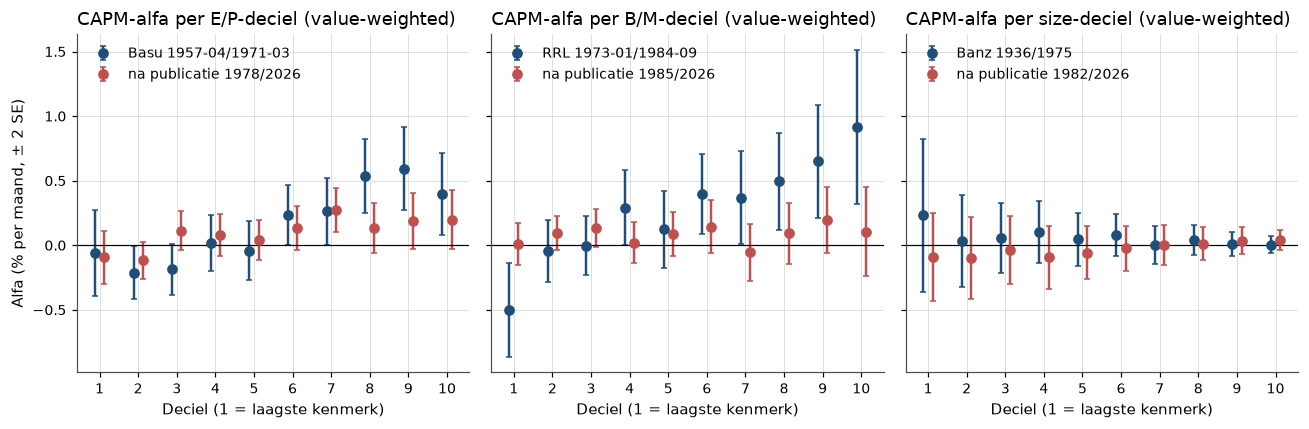

In [11]:
decile_periods = {"E/P": list(periods["E/P"].items())[:2], "B/M": list(periods["B/M"].items())[:2],
                  "size": list(periods["size"].items())[:2]}
fig, axes = plt.subplots(1, 3, figsize=(12, 4.0), sharey=True)
for ax, (sort, spans) in zip(axes, decile_periods.items()):
    for (label, (a, b)), color, shift in zip(spans, hap.plotting.COLORS, (-0.12, 0.12)):
        table = pd.DataFrame({d: capm_row(panels[(sort, "VW")][d].loc[a:b]) for d in deciles}).T
        se_alpha = table["alfa (% p.m.)"] / table["t(alfa)"]
        ax.errorbar(np.arange(1, 11) + shift, table["alfa (% p.m.)"], yerr=2 * se_alpha,
                    fmt="o", capsize=2, color=color, label=label)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"CAPM-alfa per {sort}-deciel (value-weighted)")
    ax.set_xlabel("Deciel (1 = laagste kenmerk)")
    ax.set_xticks(range(1, 11))
    ax.legend(loc="upper left")
axes[0].set_ylabel("Alfa (% per maand, ± 2 SE)")
fig.tight_layout()
plt.show()

:::{figure} #cel-vroege-anomalieen-decielen
:label: fig-vroege-anomalieen-decielen
:width: 100%

CAPM-alfa's per deciel in de oorspronkelijke steekproef en na publicatie. Voor E/P
lopen de alfa's in Basu's periode op van rond nul in de laagste decielen naar
0,4–0,6% per maand in de hoogste drie; voor B/M in de periode van Rosenberg, Reid en
Lanstein vrijwel monotoon van $-0{,}50\%$ ($t = -2{,}7$) naar $0{,}92\%$ ($t = 3{,}1$).
Voor size springt alleen het kleinste deciel eruit, met een foutbalk die nul ruim
bevat: Banz' effect zat in een kleinere groep bedrijven dan dit deciel. Na publicatie
zijn alle drie de profielen vlakker en liggen ze dichter bij nul.
:::

### Het januari-effect

Keims vraag: in welke maand wordt de size-premie verdiend? We splitsen het
klein-min-groot-rendement naar januari en de overige maanden, in zijn periode en
daarna. De "bijdrage van januari" is het januarigemiddelde gedeeld door de som
van de twaalf maandgemiddelden, dus het deel van de jaarpremie dat in januari valt;
we rapporteren haar alleen als januari en de overige maanden allebei niet negatief zijn.

In [12]:
def january_split(series):
    """Mean and t of January versus February-December returns, and January's share of the annual sum."""
    jan, rest = series[series.index.month == 1], series[series.index.month != 1]
    annual = jan.mean() + 11 * rest.mean()
    return {"januari (% p.m.)": 100 * jan.mean(), "t januari": jan.mean() / (jan.std() / np.sqrt(len(jan))),
            "feb-dec (% p.m.)": 100 * rest.mean(), "t feb-dec": rest.mean() / (rest.std() / np.sqrt(len(rest))),
            "jaarpremie (%)": 100 * annual, "bijdrage januari": jan.mean() / annual if min(jan.mean(), rest.mean()) >= 0 else np.nan,
            "jaren": len(jan)}


january = pd.DataFrame(
    {(label, w): january_split(long_short("size", w).loc[a:b])
     for label, (a, b) in {"Keim 1963-1979": ("1963-01", "1979-12"), "1926-1962": ("1926-07", "1962-12"),
                           "na 1980": ("1980-01", "2026-07")}.items()
     for w in ("VW", "EW")}
).T
january.round(3)

januari (% p.m.)  t januari  feb-dec (% p.m.)  t feb-dec  \
Keim 1963-1979 VW             8.332      6.407             0.170      0.494   
               EW            10.298      7.445             0.261      0.758   
1926-1962      VW             9.362      5.274             0.100      0.205   
               EW            12.044      5.231             0.611      1.177   
na 1980        VW             2.739      3.412            -0.305     -1.587   
               EW             5.611      5.298            -0.489     -2.574   

                   jaarpremie (%)  bijdrage januari  jaren  
Keim 1963-1979 VW          10.199             0.817   17.0  
               EW          13.164             0.782   17.0  
1926-1962      VW          10.465             0.895   36.0  
               EW          18.765             0.642   36.0  
na 1980        VW          -0.616               NaN   47.0  
               EW           0.234               NaN   47.0

In Keims periode verdiende de equal-weighted klein-min-groot-portefeuille in januari
gemiddeld 10,3%, met $t = 7{,}45$ over zeventien januari's, en in elk van de overige
maanden 0,26% ($t = 0{,}76$): januari draagt 78% van de jaarpremie van 13,2%,
value-weighted 82%. Dat is meer dan de "bijna vijftig procent" van Keim, die met
voor risico gecorrigeerde dagrendementen werkte. Over 1926–1962 is het beeld
hetzelfde. Na 1980 levert januari nog 5,6% op ($t = 5{,}30$), maar presteren kleine
aandelen in de andere maanden *slechter* dan grote ($-0{,}49\%$ per maand,
$t = -2{,}57$): de jaarpremie is vrijwel nul. Een risicopremie die alleen in januari
wordt betaald, is moeilijk als risicopremie te verdedigen; de gangbare verklaringen
(verkopen om fiscale verliezen te nemen in december, window dressing door
fondsbeheerders) zijn institutioneel.

### Fama-MacBeth met bèta en marktwaarde

Banz stelde de vraag in de vorm van [](#eq-vroege-anomalieen-fm): voegt marktwaarde
iets toe naast bèta? We draaien Fama-MacBeth op de tien size-decielen, met
rollende bèta's uit de voorgaande 60 maanden en de log van de gemiddelde
bedrijfsgrootte per deciel ten opzichte van het gemiddelde over de decielen, beide
bekend op het moment van de cross-sectie.

In [13]:
size_vw = panels[("size", "VW")]
avg_size = hap_data.french("Portfolios_Formed_on_ME", table=5)[deciles]
log_rel_size = np.log(avg_size).sub(np.log(avg_size).mean(axis=1), axis=0).shift(1)
rolling_beta = (size_vw.rolling(60).cov(mkt_excess.loc[size_vw.index])
                .div(mkt_excess.loc[size_vw.index].rolling(60).var(), axis=0).shift(1))


def fm_size(a, b, with_size=True):
    """Fama-MacBeth on the ten size deciles over [a, b] (estimates in % per month)."""
    chars = {"bèta": rolling_beta.loc[a:b]}
    if with_size:
        chars["log relatieve size"] = log_rel_size.loc[a:b]
    out = hap.stats.fama_macbeth(size_vw.loc[a:b], chars, lags=0)
    out.attrs = {}
    return out[["estimate", "tstat", "n_periods"]].assign(estimate=lambda d: 100 * d["estimate"])


pd.concat({
    ("Banz 1936-1975", "bèta"): fm_size("1936-01", "1975-12", with_size=False),
    ("Banz 1936-1975", "bèta + size"): fm_size("1936-01", "1975-12"),
    ("na 1982", "bèta + size"): fm_size("1982-01", "2026-07"),
}).round(3)

estimate  tstat  n_periods
Banz 1936-1975 bèta        const                 -0.053 -0.104        480
                           bèta                   0.728  1.371        480
               bèta + size const                  1.034  1.663        480
                           bèta                  -0.119 -0.236        480
                           log relatieve size    -0.106 -1.552        480
na 1982        bèta + size const                  0.211  0.507        535
                           bèta                   0.514  1.156        535
                           log relatieve size     0.038  1.140        535

In Banz' periode is de coëfficiënt op de log relatieve omvang $-0{,}11\%$ per
maand ($t = -1{,}55$): het teken van Banz, maar op tien portefeuilles waarin bèta en
omvang bijna perfect samenhangen niet scherp gemeten. Met alleen bèta is de helling
0,73% per maand ($t = 1{,}37$); zodra size erbij komt, zakt ze naar $-0{,}12\%$. Na
1982 is de size-coëfficiënt positief en insignificant (0,04%, $t = 1{,}14$). Een
regressie op tien portefeuilles die op één kenmerk zijn gesorteerd, kan bèta en dat
kenmerk niet scheiden: die cross-sectie heeft in feite één dimensie.

## Wat er brak, en wat daarna kwam

**Wat het CAPM verklaart.** Nog steeds veel. De markt verklaart het grootste deel
van de variantie van elke decielportefeuille, en de anomalieën zijn verschillen van
enkele tienden van een procent per maand, gemeten met standaardfouten van dezelfde
orde. Geen
van de vier artikelen stelde een ander model voor. Reinganum las zijn resultaten zelfs uitdrukkelijk als bewijs dat het
evenwichtsmodel verkeerd was gespecificeerd en niet dat de markt inefficiënt was,
omdat de abnormale rendementen minstens twee jaar aanhielden. Het CAPM bleef de theorie; het had er alleen een lijst met uitzonderingen
bij gekregen.

**Waar het breekt.** In de oorspronkelijke steekproeven hadden goedkope en kleine aandelen positieve
CAPM-alfa's met een long-short-bèta rond nul of negatief. Het scherpste feit uit
onze replicatie is de value-weighted B/M-alfa van 1,42% per maand ($t = 3{,}31$) in
de twaalf jaar van Rosenberg, Reid en Lanstein, en de equal-weighted E/P-alfa van
0,89% ($t = 4{,}53$) in Basu's veertien jaar. Keims seizoenspatroon is een barst van
een andere soort: 78% van de size-premie in één maand.

**Risico of vergissing?** De twee lezingen staan in de titels. Rosenberg, Reid en
Lanstein noemden hun artikel *Persuasive Evidence of Market Inefficiency*: een
goedkoop aandeel is een vergissing van de markt, en de B/P-strategie buit die uit.
{cite:t}`Reinganum1981` en later {cite:t}`Berk1995` gaven de andere lezing: een lage
koers ten opzichte van winst, boekwaarde of omvang *is* een hoge discontovoet, en
een model dat die discontovoet niet verklaart, is onvolledig. Onze simulatie laat
zien dat beide lezingen hetzelfde patroon voortbrengen; wat ze zou scheiden, is een
maat voor het gemiste risico die niet uit prijzen is afgeleid, en die had niemand.
Het januari-effect en het verdwijnen na publicatie passen slecht bij een
risicopremie; ze passen ook bij een derde lezing, datamining, waartegen
{cite:t}`Black1993` en {cite:t}`LoMacKinlay1990` waarschuwden. Dat de
equal-weighted waarde-alfa na 1985 bleef bestaan, pleit juist tegen datamining.
{cite:t}`Bhandari1988` vond voor de schuldgraad, een evident riskant kenmerk, een
premie die na correctie voor bèta en omvang bleef bestaan en in januari veel groter
was, en concludeerde dat ze waarschijnlijk niet zomaar een risicopremie is. Voor een belegger is het de vraag van Santa-Clara: wie in
1985 value kocht, droeg die een beprijsd risico, of dacht die iets te weten wat de
prijs niet wist? De eerlijke vaststelling is dat dezelfde transactie beide kan
zijn geweest.

**Wat er daarna kwam.** Zeven jaar later zouden Fama en French al deze kenmerken in
één cross-sectionele regressie zetten en er twee overhouden, maar eerst wendde de
theorie zich naar een ander prijsprobleem waarin kenmerken vervangen worden door
toestandsvariabelen: de rente en de waarde van flexibiliteit, in
[](#03-17-termijnstructuur-real-options).

## Oefeningen

:::{exercise}
:label: ex-vroege-anomalieen-1

**De orde van grootte van Berk.** Neem het model van
{prf:ref}`thm-vroege-anomalieen-berk` met de parameters uit simulatie (a).

1. Leid met een eerste-ordebenadering van $\log(k - g)$ rond $\bar k$ af dat
   $\Cov(\log \mathrm{ME}, k) \approx -\Var(k)/(\bar k - g)$ en
   $\Corr(\log \mathrm{ME}, k) \approx -\SD(k)/\left((\bar k - g)\,\SD(\log \mathrm{ME})\right)$.
2. Bereken beide benaderingen voor `k_i` en `log_me` en vergelijk ze met de
   steekproefwaarden.
3. Hoe verandert de correlatie als de spreiding van $\log C_i$ halveert? Wat
   betekent dat voor B/M, waar de schaal van de kasstroom deels wegvalt?
:::

:::{solution} ex-vroege-anomalieen-1
:class: dropdown

**(1)** Met $h(k) = \log(k-g) \approx h(\bar k) + (k - \bar k)/(\bar k - g)$ en de
onafhankelijkheid van $\log C$ is
$\Cov(\log \mathrm{ME}, k) = -\Cov(h(k), k) \approx -\Var(k)/(\bar k - g)$. Delen
door $\SD(k)\,\SD(\log \mathrm{ME})$ geeft de correlatie.

**(2) en (3)**

In [14]:
def berk_approximation(log_cash_sd):
    log_me_alt = log_cash_sd / 1.5 * (log_me + np.log(k_i - 0.02)) - np.log(k_i - 0.02)
    cov_approx = -k_i.var() / (k_i.mean() - 0.02)
    return {"cov steekproef": np.cov(log_me_alt, k_i)[0, 1], "cov benadering": cov_approx,
            "corr steekproef": np.corrcoef(log_me_alt, k_i)[0, 1],
            "corr benadering": cov_approx / (k_i.std() * log_me_alt.std())}


pd.DataFrame({"SD log C = 1.5": berk_approximation(1.5), "SD log C = 0.75": berk_approximation(0.75)}).round(4)

,SD log C = 1.5,SD log C = 0.75
cov steekproef,-0.0083,-0.0080
cov benadering,-0.0072,-0.0072
corr steekproef,-0.1931,-0.3552
corr benadering,-0.1681,-0.3198


De benadering zit dicht bij de steekproefwaarden; de kleine afwijking komt van de
kromming van de logaritme, die bedrijven met $k$ dicht bij $g$ extra groot maakt.
Bij een halvering van de kasstroomspreiding wordt de correlatie bijna twee keer
zo sterk. Dat is de reden dat verhoudingen zoals B/M en E/P betere thermometers
voor verwacht rendement zijn dan marktwaarde alleen: de noemer haalt een deel van
de ruis in het niveau van de kasstroom weg.
:::

:::{exercise}
:label: ex-vroege-anomalieen-2

**Is value ook een januari-effect?** {cite:t}`Bhandari1988` vond zijn
schuldgraad-effect vooral in januari.

1. Pas `january_split` toe op de hoog-min-laag-portefeuilles van E/P en B/M,
   equal- en value-weighted, voor 1963–1984 en voor 1985–2026.
2. Zit de waarde-premie net zo sterk in januari als de size-premie?
3. Wat zegt het verschil over de vraag of E/P en B/M "gewoon size" zijn, de vraag
   van {cite:t}`Reinganum1981`?
:::

:::{solution} ex-vroege-anomalieen-2
:class: dropdown

In [15]:
pd.DataFrame(
    {(sort, label, w): january_split(long_short(sort, w).loc[a:b])
     for sort in ("E/P", "B/M")
     for label, (a, b) in {"1963-1984": ("1963-07", "1984-12"), "1985-2026": ("1985-01", "2026-07")}.items()
     for w in ("VW", "EW")}
).T.round(3)

januari (% p.m.)  t januari  feb-dec (% p.m.)  t feb-dec  \
E/P 1963-1984 VW             5.236      4.493             0.259      0.955   
              EW             2.146      2.490             0.616      3.176   
    1985-2026 VW            -0.571     -0.727             0.133      0.652   
              EW             0.655      1.311             0.440      3.042   
B/M 1963-1984 VW             6.686      5.637             0.299      1.118   
              EW             6.068      5.174             0.672      2.946   
    1985-2026 VW             1.087      1.089             0.108      0.466   
              EW             2.491      2.514             0.775      4.172   

                  jaarpremie (%)  bijdrage januari  jaren  
E/P 1963-1984 VW           8.087             0.647   21.0  
              EW           8.924             0.240   21.0  
    1985-2026 VW           0.892               NaN   42.0  
              EW           5.495             0.119   42.0  
B/M 1963-1984 VW           9.980             0.670   21.0  
              EW          13.455             0.451   21.0  
    1985-2026 VW           2.271             0.479   42.0  
              EW          11.015             0.226   42.0

In 1963–1984 zit de value-weighted waarde-premie, net als de size-premie, voor
twee derde in januari: 65% voor E/P en 67% voor B/M, met januari-$t$-waarden van
4,5 en 5,6. Equal-weighted is dat veel minder, 24% en 45%, met significante
premies in de overige maanden ($t = 3{,}18$ en $2{,}95$). Na 1985 verdient de
equal-weighted B/M-portefeuille 0,78% per maand buiten januari ($t = 4{,}17$), en
valt maar 23% van haar jaarpremie in januari. Een effect dat buiten januari
bestaat, terwijl de size-premie dat niet doet, is niet simpelweg size: dat pleit
tegen de lezing dat E/P en B/M alleen omvang meten, al kan een sortering op één
kenmerk het niet definitief beslissen.

De oefening laat zien dat een seizoenspatroon een tweede dimensie is waarop
anomalieën van elkaar verschillen: wie alleen jaargemiddelden vergelijkt, ziet
drie keer hetzelfde effect, wie per maand kijkt, ziet dat ze niet volledig
samenvallen.
:::

:::{exercise}
:label: ex-vroege-anomalieen-3

**Hoeveel kandidaten voor $t > 3$?** In een wereld zonder enig effect zijn de
$t$-waarden van $K$ onafhankelijke kenmerken standaardnormaal.

1. Leid af hoeveel kandidaten $K$ een onderzoeker nodig heeft om met kans 50%
   minstens één $t > 1{,}96$ te vinden, en hoeveel voor $t > 3$ (eenzijdig).
2. Controleer je antwoord met een simulatie van 20 000 onderzoekers.
3. Hoe verandert het antwoord als de kenmerken onderling gecorreleerd zijn, zoals
   E/P, B/M en omvang in de replicatie?
:::

:::{solution} ex-vroege-anomalieen-3
:class: dropdown

**(1)** $P(\max_k t_k > c) = 1 - \Phi(c)^K = 0{,}5$ geeft
$K = \log 0{,}5 / \log \Phi(c)$: voor $c = 1{,}96$ is $\Phi(c) = 0{,}975$ en
$K = 27{,}4$, dus 28 kandidaten; voor $c = 3$ is $\Phi(c) = 0{,}99865$ en
$K = 513{,}4$, dus 514.

**(2)**

In [16]:
n_researchers = 20_000
rows = {}
for c in (1.96, 3.0):
    K = int(np.ceil(np.log(0.5) / np.log(stats.norm.cdf(c))))
    best = np.array([rng.standard_normal(K).max() for _ in range(n_researchers)])
    rows[f"c = {c}"] = {"K": K, "gesimuleerde kans max t > c": np.mean(best > c)}
pd.DataFrame(rows).T.round(3)

,K,gesimuleerde kans max t > c
c = 1.96,28.0,0.504
c = 3.0,514.0,0.502


**(3)** Positief gecorreleerde kenmerken tellen als minder onafhankelijke toetsen,
dus er zijn meer kandidaten nodig; bij perfecte correlatie zijn $K$ kandidaten er
één. Dat is een schrale troost: de literatuur na 1985 probeerde er honderden, en de
drempel $t > 3$ uit [](#06-34-factor-zoo) is een correctie in precies deze geest.
"Significant" is een uitspraak over het aantal pogingen, niet alleen over de data.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->